# Anomaly Detection on Insurance Claims

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

Unusual claims are worth a human's attention — for fraud, error, or simply data issues. This notebook
uses an **Isolation Forest** to surface the most anomalous claims in a **synthetic** dataset and turn
the scores into a prioritized review queue.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.25})
rng = np.random.default_rng(9)


## 1. Synthetic claims (mostly normal, a few planted anomalies)

In [2]:
N = 2000
amount = rng.gamma(3.0, 1500, N)                     # claim amount
days_to_report = rng.poisson(7, N) + 1               # reporting lag
prior_claims = rng.poisson(0.5, N)
df = pd.DataFrame({"amount":amount.round(0), "days_to_report":days_to_report, "prior_claims":prior_claims})

# plant 25 obvious anomalies (huge amount + long lag + many priors)
idx = rng.choice(N, 25, replace=False)
df.loc[idx, "amount"] *= rng.uniform(6, 12, 25)
df.loc[idx, "days_to_report"] += rng.integers(40, 120, 25)
df.loc[idx, "prior_claims"] += rng.integers(4, 9, 25)
df["is_planted"] = 0; df.loc[idx, "is_planted"] = 1
df.head()


,amount,days_to_report,prior_claims,is_planted
0,2338.0,10,1,0
1,1160.0,3,0,0
2,7505.0,7,1,0
3,5150.0,7,0,0
4,3110.0,7,0,0


## 2. Fit Isolation Forest & score

In [3]:
feat = ["amount","days_to_report","prior_claims"]
iso = IsolationForest(contamination=0.02, random_state=1).fit(df[feat])
df["anomaly_score"] = -iso.score_samples(df[feat])   # higher = more anomalous
df["flagged"] = (iso.predict(df[feat]) == -1).astype(int)

caught = df[df.is_planted==1]["flagged"].mean()
print(f"Flagged {df.flagged.sum()} of {N} claims for review "
      f"({df.flagged.mean():.1%}); caught {caught:.0%} of planted anomalies.")


Flagged 40 of 2000 claims for review (2.0%); caught 100% of planted anomalies.


## 3. Visualize & build the review queue

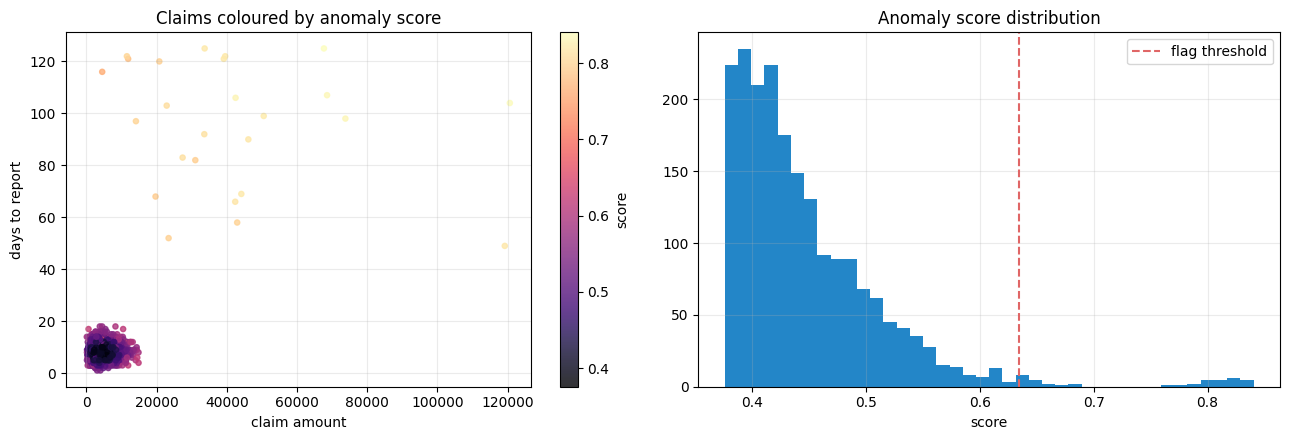

,amount,days_to_report,prior_claims,anomaly_score
1916,67681.16,125,7,0.84
1698,120641.61,104,4,0.84
945,68574.97,107,7,0.83
972,73799.08,98,5,0.83
72,42512.55,106,8,0.83
1255,50530.29,99,5,0.82
873,39158.34,121,5,0.82
17,39552.46,122,5,0.82
988,44156.14,69,10,0.82
1277,33703.43,125,5,0.82


In [4]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
sc = ax[0].scatter(df.amount, df.days_to_report, c=df.anomaly_score, cmap="magma", s=14, alpha=.8)
ax[0].set_xlabel("claim amount"); ax[0].set_ylabel("days to report")
ax[0].set_title("Claims coloured by anomaly score"); fig.colorbar(sc, ax=ax[0], label="score")

ax[1].hist(df.anomaly_score, bins=40, color="#2386c8")
ax[1].axvline(df[df.flagged==1].anomaly_score.min(), ls="--", color="#e06666", label="flag threshold")
ax[1].set_title("Anomaly score distribution"); ax[1].set_xlabel("score"); ax[1].legend()
plt.tight_layout(); plt.show()

queue = df[df.flagged==1].sort_values("anomaly_score", ascending=False).head(10)
queue[feat+["anomaly_score"]].round(2)


## 4. Business value
- **Prioritized review** — investigators start with the top of the queue, not a random sample.
- **Unsupervised** — no labelled fraud needed; it flags what's *unusual*, then humans judge.
- **Translation** — the deliverable isn't a model; it's a ranked, explainable worklist plugged into BI.

In practice I'd pair this with domain rules and feed confirmed cases back to improve targeting over time.

*— Aman Bohra*
